# AgeLens

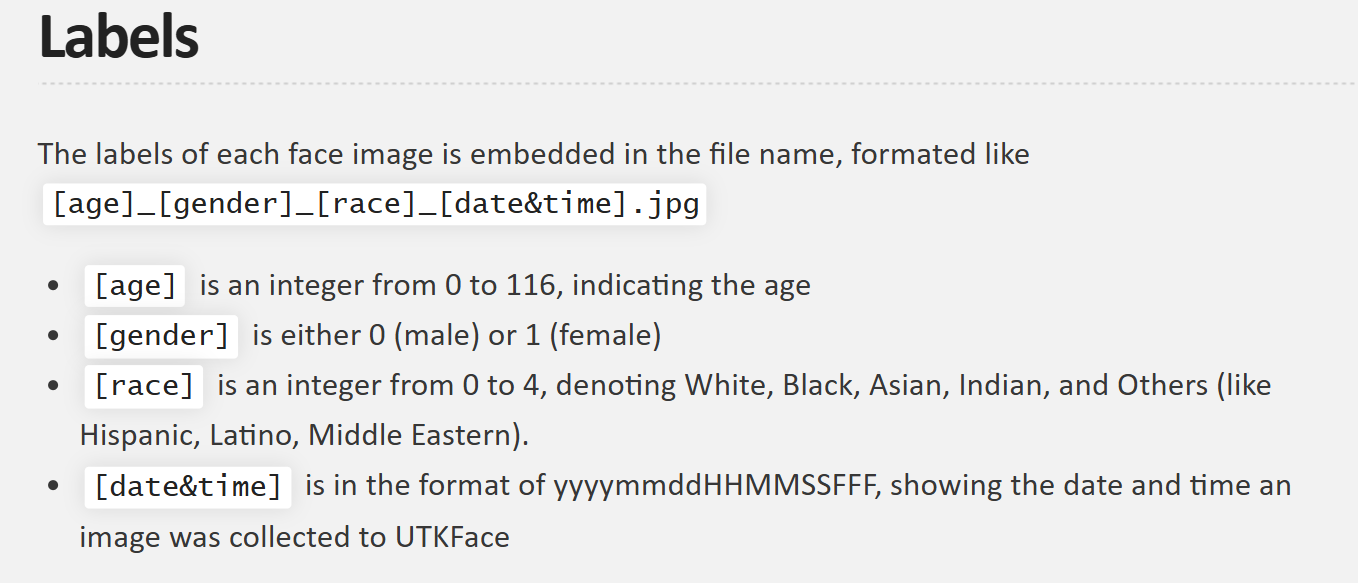

In [1]:
!pip install tensorflow
!pip install kagglehub


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Path to dataset files: /kaggle/input/utkface-new


In [4]:
#Extrahiere Datenset bzw bekomme die labels

In [5]:
import gzip
import numpy as np
from keras.utils import to_categorical


In [6]:
dataset_folder_name = ''

TRAIN_TEST_SPLIT = 0.7
IM_WIDTH = IM_HEIGHT = 198

dataset_dict = {
    'race_id': {
        0: 'white',
        1: 'black',
        2: 'asian',
        3: 'indian',
        4: 'others'
    },
    'gender_id': {
        0: 'male',
        1: 'female'
    }
}

dataset_dict['gender_alias'] = dict((g, i) for i, g in dataset_dict['gender_id'].items())
dataset_dict['race_alias'] = dict((g, i) for i, g in dataset_dict['race_id'].items())

In [7]:
import pandas as pd
import os

def parse_dataset(dataset_path):
    records = []

    # Sicherstellen, dass der Pfad existiert
    if not os.path.exists(dataset_path):
        print(f"Pfad nicht gefunden: {dataset_path}")
        return pd.DataFrame()

    for file in os.listdir(dataset_path):
        if file.endswith(".jpg"):
            try:
                # Splittet den Dateinamen: "age_gender_race_date.jpg"
                parts = file.split("_")

                # Wir brauchen mindestens 3 Teile (age, gender, race)
                if len(parts) >= 3:
                    age = int(parts[0])
                    gender = int(parts[1])
                    race = int(parts[2])
                    file_path = os.path.join(dataset_path, file)

                    # Wir fügen ein Dictionary hinzu – das erkennt Pandas automatisch als Zeile
                    records.append({
                        'age': age,
                        'gender': gender,
                        'race': race,
                        'file': file_path
                    })
            except (ValueError, IndexError):
                # Falls ein Dateiname nicht dem Schema entspricht, einfach überspringen
                continue

    df = pd.DataFrame(records)

    return df





In [8]:
import numpy as np
import pandas as pd
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
def parse_dataset(dataset_path, ext='jpg'):
    """
    Used to extract information about our dataset. It does iterate over all images and return a DataFrame with
    the data (age, gender and sex) of all files.
    """
    def parse_info_from_file(path):
        """
        Parse information from a single file
        """
        try:
            filename = os.path.split(path)[1]
            filename = os.path.splitext(filename)[0]
            age, gender, race, _ = filename.split('_')

            return int(age), dataset_dict['gender_id'][int(gender)], dataset_dict['race_id'][int(race)]
        except Exception as ex:
            return None, None, None

    files = glob.glob(os.path.join(dataset_path, "*.%s" % ext))

    records = []
    for file in files:
        info = parse_info_from_file(file)
        records.append(info)

    df = pd.DataFrame(records)

    df['file'] = files
    df.columns = ['age', 'gender', 'race', 'file']
    df = df.dropna()


    return df

In [10]:
!pip install scikit-learn

In [20]:
import os
import glob
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

def load_data_and_labels(base_path, target_size=(28, 28)):
    if not os.path.exists(base_path):
        print(f"FEHLER: Der Pfad {base_path} existiert nicht.")
        return np.array([]), pd.DataFrame()

    # Effiziente Suche nach .jpg Dateien
    files = glob.glob(os.path.join(base_path, "*.jpg"))
    # Manche Dateien auf Kaggle sind .JPG statt .jpg
    if not files:
        files = glob.glob(os.path.join(base_path, "*.JPG"))

    files = list(set(files)) # Duplikate entfernen

    images = []
    labels = []

    print(f"Dateien gefunden: {len(files)}")

    for f in files:
        basename = os.path.basename(f)
        parts = basename.split('_')

        # Validierung der Dateinamen-Struktur
        if len(parts) >= 3:
            try:
                # WICHTIG: Erst alle Daten extrahieren, bevor wir sie den Listen hinzufügen
                age = int(parts[0])
                gender = int(parts[1])
                race = int(parts[2])

                # Bild laden und vorverarbeiten
                img = Image.open(f).convert('L')
                img = img.resize(target_size, Image.Resampling.LANCZOS)

                # Nur wenn ALLES geklappt hat, fügen wir Bild UND Label hinzu
                images.append(np.array(img))
                labels.append({
                    'age': age,
                    'gender': gender,
                    'race': race
                })
            except Exception:
                # Korrupte Bilder oder falsche Dateinamen werden hier übersprungen
                continue

    if not images:
        print("FEHLER: Keine gültigen Daten gefunden.")
        return np.array([]), pd.DataFrame()

    # Umwandlung in NumPy Arrays & Normalisierung
    X = np.array(images).astype('float32') / 255.0
    X = X.reshape(-1, target_size[0], target_size[1], 1)
    y = pd.DataFrame(labels)

    print(f"Erfolgreich verarbeitet: {len(X)} Bilder")
    return X, y

# --- KONFIGURATION ---
dataset_path = '/kaggle/input/utkface-new/UTKFace'
seed = 42

# 1. Daten laden
X_all, y_all = load_data_and_labels(dataset_path)

# 2. Split durchführen
if len(X_all) > 0:
    # 70% Train, 30% Rest
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_all, y_all, test_size=0.30, random_state=seed, stratify=y_all['gender']
    )

    # Rest aufteilen in 15% Val und 15% Test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp['gender']
    )

    print("-" * 30)
    print(f"Split abgeschlossen:")
    print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
else:
    print("Keine Daten zum Splitten vorhanden.")

Dateien gefunden: 23708
Erfolgreich verarbeitet: 23705 Bilder
------------------------------
Split abgeschlossen:
Train: 16593 | Val: 3556 | Test: 3556


# Model Training

In [33]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import to_categorical

# 1. Labels vorbereiten (Beispiel: Gender)
# Wir wandeln die 0/1 Werte in One-Hot-Vektoren um
y_train_gender = to_categorical(y_train['gender'], num_classes=2)

# 2. Modell anpassen
model = Sequential()
model.add(Input(shape=(784,))) # Neue Schreibweise um die UserWarning zu vermeiden
model.add(Dense(500, activation="sigmoid"))
model.add(Dense(2, activation="sigmoid")) # 2 Neuronen für Gender (Mann/Frau)

model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

# 3. Training
# Nutze dynamisches Reshape, falls sich die Anzahl der Bilder ändert
model.fit(
    X_train.reshape(-1, 784),
    y_train_gender,
    y_train
    epochs=50,
    batch_size=1000
)

model.save('AgeLensModell.keras')

Epoch 1/50


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 3), output.shape=(None, 2)